# Homework Sessions 1-3, Part A
**Computer Vision and Speech Recognition, EADA** · MILK10k · Bruno Curi · repo: https://github.com/bporto-eada/milk10k-eda

The notebook runs top to bottom (*Restart & Run All*). The data folder comes from `shared/config.py`: environment
variable `MILK10K_DIR`, default `milk10k/` at the repo root, so there are no absolute paths here. Functions that the
Part B pipeline reuses live in the `shared/` package; when an exercise asks for one of them, the cell prints its
source so the code is visible in this PDF.

In [1]:
import inspect
import io
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image

from shared import checks, config, data, paths, splits

pd.set_option("display.width", 110)
SEED = config.SEED
CLASSES_3 = ["Benign", "Indeterminate", "Malignant"]


def show_source(*objects):
    # print the code of functions that live in shared/ (reused by Part B)
    for obj in objects:
        print(inspect.getsource(obj))


meta = data.load_metadata()             # metadata.csv, one row per image
gt = data.load_ground_truth()           # training_gt.csv, one row per lesion, plus dx
images = data.load_tables()             # metadata + dx
lesions = data.build_lesion_table(images)   # one row per lesion, built and checked in A1.3
print(f"data folder: {paths.shown(config.DATA_DIR)}/ | {len(meta):,} images | "
      f"{len(gt):,} lesions in training_gt.csv")

data folder: milk10k/ | 10,480 images | 5,240 lesions in training_gt.csv


## A1. Session 1: trusting and shaping the data
### A1.1 Cross-check the two label files

In [2]:
show_source(checks.compare_lesion_ids, checks.one_hot_violations, checks.class_to_diagnosis_1,
            checks.ambiguous_classes, checks.hierarchy_violations, checks.inconsistent_lesions)

def compare_lesion_ids(meta, gt):
    """(a) lesion_ids that appear in only one of the two label files."""
    in_meta, in_gt = set(meta["lesion_id"]), set(gt["lesion_id"])
    return {"only_in_metadata": sorted(in_meta - in_gt), "only_in_gt": sorted(in_gt - in_meta)}

def one_hot_violations(gt):
    """(b) training_gt rows without exactly one positive class, or with values other than 0/1."""
    values = gt[config.SUBCLASSES]
    bad = (values.sum(axis=1) != 1) | ~values.isin([0, 1]).all(axis=1)
    return gt.loc[bad, ["lesion_id"] + config.SUBCLASSES]

def class_to_diagnosis_1(lesions):
    """(c) lesion counts: 11-class label (rows) by diagnosis_1 (columns)."""
    return pd.crosstab(lesions["dx"], lesions["diagnosis_1"])

def ambiguous_classes(table):
    """(c) rows of the class -> diagnosis_1 table that hit more than one diagnosis_1 value."""
    return table[(table > 0).sum(axis=1) > 1]

def hierarchy_violations(meta, child, parent):
    """(d) non-missing child values that sit 

In [3]:
ids = checks.compare_lesion_ids(meta, gt)                                  # (a)
one_hot = checks.one_hot_violations(gt)                                    # (b)
mapping = checks.class_to_diagnosis_1(lesions)                             # (c)
ambiguous = checks.ambiguous_classes(mapping)
d3_d2 = checks.hierarchy_violations(meta, "diagnosis_3", "diagnosis_2")    # (d)
d2_d1 = checks.hierarchy_violations(meta, "diagnosis_2", "diagnosis_1")
disagree = checks.inconsistent_lesions(meta)                               # (e)

summary = pd.DataFrame({
    "check": ["(a) same lesion_id set in both files", "(b) exactly one positive class per gt row",
              "(c) class maps to one diagnosis_1", "(d) diagnosis_3 under one diagnosis_2",
              "(d) diagnosis_2 under one diagnosis_1", "(e) both images agree (age, sex, site, dx)"],
    "violations": [len(ids["only_in_metadata"]) + len(ids["only_in_gt"]), len(one_hot),
                   len(ambiguous), len(d3_d2), len(d2_d1), int(disagree.sum())]})
print(summary.to_string(index=False))
print("\n(c) lesions per 11-class label and diagnosis_1:")
print(mapping.to_string())
print("\n(c) classes that do NOT map to exactly one diagnosis_1:")
print(ambiguous.to_string())
print("\n(e) lesions whose two images disagree, per field:")
print(disagree.to_string())

assert not ids["only_in_metadata"] and not ids["only_in_gt"], ids
assert one_hot.empty, one_hot
assert d3_d2.empty and d2_d1.empty
assert disagree.sum() == 0
print("\nasserts (a), (b), (d), (e) passed; (c) is a finding, discussed below")

                                     check  violations
      (a) same lesion_id set in both files           0
 (b) exactly one positive class per gt row           0
         (c) class maps to one diagnosis_1           1
     (d) diagnosis_3 under one diagnosis_2           0
     (d) diagnosis_2 under one diagnosis_1           0
(e) both images agree (age, sex, site, dx)           0

(c) lesions per 11-class label and diagnosis_1:
diagnosis_1  Benign  Indeterminate  Malignant
dx                                           
AKIEC             0            123        180
BCC               0              0       2522
BEN_OTH          44              0          0
BKL             544              0          0
DF               52              0          0
INF              50              0          0
MAL_OTH           0              0          9
MEL               0              0        450
NV              746              0          0
SCCKA             0              0        473
VASC          

**Answer.** (c) Ten of the 11 classes map to a single diagnosis_1 value, but AKIEC does not: its 303 lesions are
123 Indeterminate and 180 Malignant, and those 123 are all the Indeterminate lesions in the dataset (actinic
keratoses, while the malignant part is squamous cell carcinoma in situ). So diagnosis_1 cannot be derived from an
11-class prediction: a predicted AKIEC would be wrong for 41% or 59% of those lesions whichever value we pick, and
Indeterminate could never be predicted at all, which is why the project trains diagnosis_1 as its own target and
stratifies the splits on both labels. Checks (a), (b), (d) and (e) passed, and I would repeat all five on any new
medical dataset before training. The most dangerous failure is a silent one such as (b): `idxmax` on a row with
two positive classes just returns the first, so the pipeline runs and a malignant lesion can be trained as benign
without any error.

### A1.2 Ask the data five questions

In [4]:
# 1. BCC lesions in patients aged 70+ on the head/neck (lesion level)
q1 = lesions.query("dx == 'BCC' and age >= 70 and site == 'head/neck'")
share = len(q1) / (lesions["dx"] == "BCC").sum()
print(f"Q1: {len(q1)} BCC lesions in patients aged 70+ on the head/neck ({share:.0%} of all BCC)")

# 2. class with the highest share of 'altered' images (image level)
altered = (images.assign(altered=images["image_manipulation"].eq("altered"))
           .groupby("dx")["altered"].mean().mul(100).sort_values(ascending=False))
print(f"Q2: {altered.index[0]} has the most altered images: {altered.iloc[0]:.1f}% "
      f"(next: {altered.index[1]} {altered.iloc[1]:.1f}%, overall "
      f"{images['image_manipulation'].eq('altered').mean():.1%})")

# 3. youngest and oldest melanoma patient
mel = lesions.loc[lesions["dx"] == "MEL", "age"]
print(f"Q3: melanoma ages run from {mel.min():.0f} to {mel.max():.0f}, a gap of "
      f"{mel.max() - mel.min():.0f} years (ages are 5-year bins)")

# 4. is a missing site informative? class mix with and without a recorded site
recorded = lesions["site"].notna().map({True: "site recorded", False: "site missing"})
mix = pd.crosstab(lesions["dx"], recorded, normalize="columns").mul(100)
mix["difference_pp"] = mix["site missing"] - mix["site recorded"]
top = mix["difference_pp"].abs().idxmax()
print(f"Q4: {lesions['site'].isna().mean():.1%} of lesions have no site; {top} changes most: "
      f"{mix.loc[top, 'difference_pp']:+.1f} pp")
print(mix.round(1).sort_values("difference_pp").to_string())

# 5. share of Malignant lesions per confirmation type
confirm = meta.drop_duplicates("lesion_id")[["lesion_id", "diagnosis_confirm_type"]]
q5 = (lesions.merge(confirm, on="lesion_id").groupby("diagnosis_confirm_type")
      .agg(lesions=("lesion_id", "size"),
           malignant_pct=("diagnosis_1", lambda s: (s == "Malignant").mean() * 100)))
print("\nQ5:")
print(q5.round(1).to_string())

Q1: 380 BCC lesions in patients aged 70+ on the head/neck (15% of all BCC)
Q2: BEN_OTH has the most altered images: 18.2% (next: INF 8.0%, overall 3.2%)
Q3: melanoma ages run from 20 to 85, a gap of 65 years (ages are 5-year bins)
Q4: 37.3% of lesions have no site; NV changes most: +11.0 pp
site     site missing  site recorded  difference_pp
dx                                                 
SCCKA             2.9           12.7           -9.8
AKIEC             2.0            8.0           -6.0
DF                0.5            1.3           -0.8
BKL              10.1           10.6           -0.5
INF               0.9            1.0           -0.1
BEN_OTH           0.8            0.9           -0.1
MAL_OTH           0.3            0.1            0.2
VASC              1.2            0.7            0.4
BCC              49.3           47.4            1.9
MEL              11.0            7.2            3.8
NV               21.1           10.1           11.0

Q5:
                           

**Q4.** Yes. The 37% of lesions without a site are not a random subset: nevi are 21.1% of them against 10.1% of
lesions with a site (+11.0 pp), while SCCKA (-9.8 pp) and AKIEC (-6.0 pp) almost disappear. Nevi are typical of
the trunk and keratinocyte cancers of sun-exposed skin, and the recorded sites are only head/neck, the extremities
and oral/genital, never the torso. So a missing site most likely means "trunk", not "unknown": it carries
information and must become its own category, not be filled with the most common site.

**Q5.** Lesions confirmed by histopathology are 72.3% Malignant (5,016 lesions); lesions confirmed by a single
clinician's assessment are 2.2% Malignant (224 lesions). The dataset was built from lesions that were biopsied
because someone suspected cancer; lesions without a biopsy only got in when they looked clearly benign. That is
verification bias: inclusion depends on how suspicious the lesion looked, so the case mix (69% malignant) is far
from a normal clinic, and the confirmation type almost gives the label away, so it can never be a model input.

### A1.3 Build a lesion-level table

In [5]:
show_source(data.build_lesion_table)

assert len(lesions) == 5240
assert lesions[["derm_id", "clinical_id"]].notna().all().all()
assert lesions["lesion_id"].is_unique
config.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
lesions.to_csv(config.LESIONS_CSV, index=False)
print(f"saved {paths.shown(config.LESIONS_CSV)}, shape {lesions.shape}")
lesions.head()

def build_lesion_table(images):
    """One row per lesion, built with pivot and groupby (no loops over rows).

    derm_id and clinical_id are the isic_id of the lesion's two images. pivot raises
    if a lesion has two images of the same type, so a broken pair cannot slip through.
    """
    ids = images.pivot(index="lesion_id", columns="image_type", values="isic_id")
    ids = ids.rename(columns={t: f"{short}_id" for t, short in config.IMAGE_TYPES.items()})
    info = images.groupby("lesion_id").agg(
        diagnosis_1=("diagnosis_1", "first"),
        dx=("dx", "first"),
        age=("age_approx", "first"),
        sex=("sex", "first"),
        site=("anatom_site_general", "first"),
    )
    lesions = ids[["derm_id", "clinical_id"]].join(info).reset_index()
    lesions.columns.name = None
    return lesions[LESION_COLUMNS]

saved outputs/lesions.csv, shape (5240, 8)


,lesion_id,derm_id,clinical_id,diagnosis_1,dx,age,sex,site
0,IL_0000652,ISIC_4671410,ISIC_8149219,Malignant,BCC,70.0,male,head/neck
1,IL_0003176,ISIC_5371928,ISIC_3904045,Malignant,BCC,45.0,female,head/neck
2,IL_0004688,ISIC_3624913,ISIC_0791494,Malignant,BCC,50.0,male,lower extremity
3,IL_0005081,ISIC_5186409,ISIC_5667730,Malignant,SCCKA,45.0,male,head/neck
4,IL_0006177,ISIC_1048297,ISIC_8803389,Malignant,BCC,75.0,male,upper extremity


### A1.4 Task framing

**Input:** both images of a lesion, dermoscopic and clinical close-up, since a dermatologist uses both; later
optionally age, sex and body site, never the diagnosis-derived fields. **Output:** one probability per class
(Benign, Indeterminate, Malignant) per lesion; 11 classes as a stretch goal. **User and moment:** a dermatologist or
GP during the consultation, after the dermoscopic photo and before deciding to biopsy, refer or reassure: a second
reader for triage. **Metric:** recall of Malignant at a fixed specificity, plus balanced accuracy, because 69% of
lesions are Malignant and plain accuracy rewards always answering "Malignant"; calibration matters because the
probability drives a decision. **Costlier error:** a missed malignancy (melanoma or SCC sent home) is far worse than
an unnecessary biopsy. **How MILK10k differs from use:** (1) prevalence: lesions entered because they were
biopsied, so most are malignant, unlike the lesions a clinic sees every day; (2) acquisition: images come from the
study's own devices, all resized to 600x450 JPEG, mostly middle skin tones, so other cameras, compression and
darker skin may behave differently.

## A2. Session 2: working with pixels
### A2.1 Arrays, views and memory

In [6]:
path = paths.find_image(lesions["derm_id"].iloc[0])
img = np.array(Image.open(path).convert("RGB"))     # writable uint8 array (H, W, 3)
pil = Image.fromarray(img)

numpy_ops = {   # NumPy indexing and axis operations only
    "left-right flip": (lambda a: a[:, ::-1], Image.Transpose.FLIP_LEFT_RIGHT),
    "up-down flip": (lambda a: a[::-1, :], Image.Transpose.FLIP_TOP_BOTTOM),
    "rotate 90 (counter-clockwise)": (lambda a: a.swapaxes(0, 1)[::-1], Image.Transpose.ROTATE_90),
    "transpose": (lambda a: a.swapaxes(0, 1), Image.Transpose.TRANSPOSE),
}
rows = []
for name, (ours, pillow_op) in numpy_ops.items():
    result = ours(img)
    assert np.array_equal(result, np.asarray(pil.transpose(pillow_op))), name
    rows.append({"operation": name, "shape": result.shape, "same as Pillow": True,
                 "view (shares memory)": np.shares_memory(result, img)})
copies = {"img.copy()": img.copy(), "np.ascontiguousarray(img[:, ::-1])": np.ascontiguousarray(img[:, ::-1]),
          "img[:, :, [2, 1, 0]] (fancy index)": img[:, :, [2, 1, 0]],
          "Pillow transpose result": np.asarray(pil.transpose(Image.Transpose.FLIP_LEFT_RIGHT))}
for name, result in copies.items():
    rows.append({"operation": name, "shape": result.shape, "same as Pillow": "",
                 "view (shares memory)": np.shares_memory(result, img)})
print(f"image {path.name}: {img.shape} {img.dtype}")
print(pd.DataFrame(rows).to_string(index=False))

image ISIC_4671410.jpg: (450, 600, 3) uint8
                         operation         shape same as Pillow  view (shares memory)
                   left-right flip (450, 600, 3)           True                  True
                      up-down flip (450, 600, 3)           True                  True
     rotate 90 (counter-clockwise) (600, 450, 3)           True                  True
                         transpose (600, 450, 3)           True                  True
                        img.copy() (450, 600, 3)                                False
np.ascontiguousarray(img[:, ::-1]) (450, 600, 3)                                False
img[:, :, [2, 1, 0]] (fancy index) (450, 600, 3)                                False
           Pillow transpose result (450, 600, 3)                                False


In [7]:
# (b) two-line experiment: writing into a view changes the original
demo = img.copy()
view = demo[:, ::-1]                    # left-right flip: a view, no pixel was copied
view[0, 0] = [255, 0, 0]                # paint the first pixel of the flipped image red ...
print("original first row, last pixel:", demo[0, -1])   # ... the original changed too

original first row, last pixel:

 [255   0   0]


**(b)** All four NumPy operations return **views**: slicing with a negative step and `swapaxes` only change the
shape and strides, so no pixel is copied (`np.shares_memory` is True). A copy appears only with `.copy()`,
`np.ascontiguousarray`, fancy indexing, or when Pillow builds a new image. The experiment shows the risk: painting
a pixel of the flipped view also paints the original, so an "augmented" view must be copied before it is modified.

In [8]:
# (c) memory budget for the whole dataset, read from the image headers (no decoding)
dims = []
for isic_id in meta["isic_id"]:
    with Image.open(paths.find_image(isic_id)) as im:
        dims.append(im.size)
dims = pd.DataFrame(dims, columns=["width", "height"])
print("distinct image sizes (width, height):", dims.value_counts().to_dict())

pixels = {"original": int((dims["width"] * dims["height"]).sum()), "224x224": len(dims) * 224 * 224}
budget = pd.DataFrame({dtype: {res: n * 3 * nbytes / 1e9 for res, n in pixels.items()}
                       for dtype, nbytes in (("uint8 (GB)", 1), ("float32 (GB)", 4))})
print(f"\nRAM to hold all {len(dims):,} RGB images at once:")
print(budget.round(2).to_string())

distinct image sizes (width, height): {(600, 450): 10480}

RAM to hold all 10,480 RGB images at once:
          uint8 (GB)  float32 (GB)
original        8.49         33.96
224x224         1.58          6.31


**(c)** Every image is 600x450, so the whole set needs 8.5 GB as uint8 and 34 GB as float32 at full resolution,
and 1.6 GB (uint8) or 6.3 GB (float32) at 224x224. A laptop with 8 to 16 GB cannot pre-load the originals, and the
float32 224 version would eat most of the memory. Instead the data stays on disk and a `Dataset`/`DataLoader`
decodes only the current batches (in parallel workers), keeps them uint8 until the transform, and converts to
float32 per batch; if decoding became the bottleneck, I would cache resized 256 px copies on disk.

### A2.2 JPEG compression, and a shortcut hiding in the file size

ISIC_2641217.jpg: file on disk 32.1 KB
 quality  size_kb  psnr_db
      95     55.2     53.8
      75     29.0     71.3
      50     23.1     37.9
      25     11.8     35.4
      10      6.5     31.8
the file on disk uses the same quantisation tables as a quality-75 re-encode: True


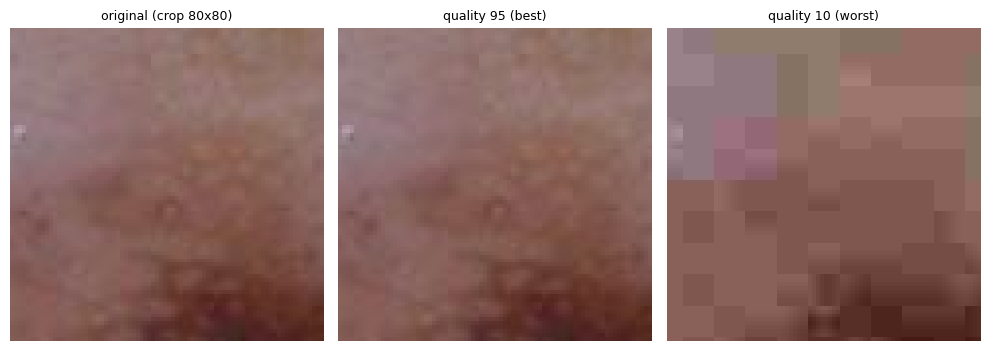

In [9]:
def psnr(reference, test):
    # peak signal-to-noise ratio in dB for 8-bit images (higher = closer to the reference)
    mse = np.mean((reference.astype(np.float64) - test.astype(np.float64)) ** 2)
    return float("inf") if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)


source = paths.find_image(lesions.loc[lesions["dx"] == "MEL", "derm_id"].iloc[0])
original = np.asarray(Image.open(source).convert("RGB"))
decoded, rows = {}, []
for quality in (95, 75, 50, 25, 10):
    buffer = io.BytesIO()
    Image.fromarray(original).save(buffer, format="JPEG", quality=quality)
    decoded[quality] = np.asarray(Image.open(io.BytesIO(buffer.getvalue())).convert("RGB"))
    rows.append({"quality": quality, "size_kb": buffer.tell() / 1024,
                 "psnr_db": psnr(original, decoded[quality])})
    if quality == 75:
        same_tables = Image.open(source).quantization == Image.open(io.BytesIO(buffer.getvalue())).quantization
print(f"{source.name}: file on disk {source.stat().st_size / 1024:.1f} KB")
print(pd.DataFrame(rows).round(1).to_string(index=False))
print("the file on disk uses the same quantisation tables as a quality-75 re-encode:", same_tables)

h, w = original.shape[:2]
crop = (slice(h // 2 - 40, h // 2 + 40), slice(w // 2 - 40, w // 2 + 40))
fig, axes = plt.subplots(1, 3, figsize=(10, 3.6))
for ax, (title, arr) in zip(axes, [("original (crop 80x80)", original), ("quality 95 (best)", decoded[95]),
                                   ("quality 10 (worst)", decoded[10])]):
    ax.imshow(arr[crop], interpolation="nearest")
    ax.set_title(title, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

**(a)** From quality 95 to 10 the re-encoded file shrinks from 55 KB to 6.5 KB and PSNR falls from 54 dB to 32 dB, with one telling exception: quality 75 scores 71 dB, far above quality 95. The file on disk was itself saved at quality 75 (same quantisation tables, printed above), so re-encoding at 75 lands on almost the same DCT coefficients, while quality 95 re-quantises them on a finer, misaligned grid and gives a bigger but slightly less faithful file. Below 75 the loss is real: the quality-10 crop shows 8x8 blocks and smeared colour, while quality 95 looks identical to the original.

**(b)** MILK10k images are already lossy JPEGs (median 31 KB for 600x450), so every image carries 8x8 block
artefacts and reduced colour resolution before the model sees it. A CNN can pick up those artefacts as texture,
and if compression differs between devices or centres it can learn them as a shortcut. Re-saving an augmented or
resized image as JPEG compresses it a second time and adds new artefacts on top of the old ones, so the pipeline
keeps decoded arrays in memory and never writes JPEGs again. Downscaling to 224 after compression averages most
block artefacts away (good), but it also mixes them into the pixels at a scale the model cannot separate; a mild
JPEG-quality augmentation would make the model robust to other cameras' compression.

distinct JPEG quantisation tables over all images: 1


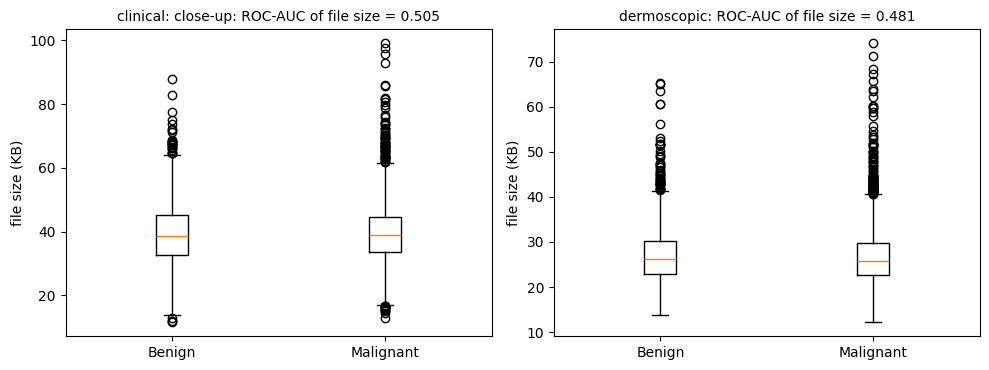

diagnosis_1         Benign  Malignant
image_type                           
clinical: close-up    38.8       38.8
dermoscopic           26.2       25.8
clinical: close-up: AUC 0.505  ->  no strong shortcut
dermoscopic: AUC 0.481  ->  no strong shortcut


In [10]:
from sklearn.metrics import roc_auc_score

files = meta[["isic_id", "image_type", "diagnosis_1", "image_manipulation"]].copy()
files["size_kb"] = [os.stat(paths.find_image(i)).st_size / 1024 for i in files["isic_id"]]
bm = files[files["diagnosis_1"].isin(["Benign", "Malignant"])]

tables = []
for isic_id in files["isic_id"]:          # quantisation tables come from the header, no decoding
    with Image.open(paths.find_image(isic_id)) as im:
        tables.append(str(im.quantization))
print("distinct JPEG quantisation tables over all images:", pd.Series(tables).nunique())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
aucs = {}
for ax, (kind, part) in zip(axes, bm.groupby("image_type")):
    ax.boxplot([part.loc[part["diagnosis_1"] == c, "size_kb"] for c in ("Benign", "Malignant")])
    ax.set_xticks([1, 2], ["Benign", "Malignant"])
    aucs[kind] = roc_auc_score(part["diagnosis_1"].eq("Malignant"), part["size_kb"])
    ax.set_title(f"{kind}: ROC-AUC of file size = {aucs[kind]:.3f}", fontsize=10)
    ax.set_ylabel("file size (KB)")
plt.tight_layout()
plt.show()
print(bm.groupby(["image_type", "diagnosis_1"])["size_kb"].median().round(1).unstack().to_string())
for kind, auc in aucs.items():
    print(f"{kind}: AUC {auc:.3f}  ->  {'shortcut' if abs(auc - 0.5) >= 0.1 else 'no strong shortcut'}")

**(c)** No. File size carries no class information: the ROC-AUC is 0.505 for clinical close-ups and 0.481 for dermoscopic images, and the medians are practically equal (38.8 vs 38.8 KB, 26.2 vs 25.8 KB). MILK10k was standardised before release: every image is 600x450 and all files share the same JPEG quantisation tables (printed above). That erases the usual culprits of a size shortcut: cameras with different resolutions or compression settings, centres with different case mixes, cropped or edited ('altered') photos, and big textured lesions or hair, rulers and gel bubbles that make files larger. The only size difference is between image types (clinical files are about 50% larger), and image type says nothing about the label. The check stays worth running: a dataset that mixes unstandardised sources would not pass it so easily.

## A3. Session 3: splits, imbalance, leakage, augmentation, datasets
### A3.1 Measure the leak

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder

NUMERIC, CATEGORICAL = ["age_approx"], ["sex", "anatom_site_general", "image_type"]
X, y, groups = images[NUMERIC + CATEGORICAL], images["diagnosis_1"], images["lesion_id"]


def metadata_forest(seed):
    # imputation and one-hot encoding sit inside the Pipeline, so they are fitted on train only
    prep = ColumnTransformer([
        ("age", SimpleImputer(strategy="median"), NUMERIC),
        ("categories", make_pipeline(SimpleImputer(strategy="constant", fill_value="missing"),
                                     OneHotEncoder(handle_unknown="ignore")), CATEGORICAL)])
    forest = RandomForestClassifier(n_estimators=200, min_samples_leaf=1, random_state=seed, n_jobs=-1)
    return Pipeline([("prep", prep), ("forest", forest)])


def naive_split(seed):      # (a) image level, stratified on diagnosis_1
    return train_test_split(np.arange(len(images)), test_size=0.2, stratify=y, random_state=seed)


def grouped_split(seed):    # (b) grouped by lesion_id, stratified on diagnosis_1
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    return next(cv.split(X, y, groups))


def sibling_oracle(train_idx, test_idx):
    # (c) label of the lesion's other image if it is in train, else the train majority class
    train_label = images.iloc[train_idx].drop_duplicates("lesion_id").set_index("lesion_id")["diagnosis_1"]
    test_lesion = groups.iloc[test_idx]
    has_sibling = test_lesion.isin(train_label.index).to_numpy()
    majority = y.iloc[train_idx].mode()[0]
    guess = np.where(has_sibling, test_lesion.map(train_label).fillna(majority), majority)
    return balanced_accuracy_score(y.iloc[test_idx], guess), has_sibling.mean() * 100


rows = []
for seed in range(5):
    for name, (tr, te) in (("naive (images)", naive_split(seed)), ("grouped (lesions)", grouped_split(seed))):
        model = metadata_forest(seed).fit(X.iloc[tr], y.iloc[tr])
        forest_ba = balanced_accuracy_score(y.iloc[te], model.predict(X.iloc[te]))
        oracle_ba, sibling_pct = sibling_oracle(tr, te)
        rows.append({"split": name, "seed": seed, "forest_bal_acc": forest_ba,
                     "oracle_bal_acc": oracle_ba, "sibling_in_train_%": sibling_pct})
leak = pd.DataFrame(rows)
columns = ["forest_bal_acc", "oracle_bal_acc", "sibling_in_train_%"]
summary = leak.groupby("split")[columns].agg(["mean", "std"])
print(summary.round(3).to_string())

                  forest_bal_acc        oracle_bal_acc        sibling_in_train_%       
                            mean    std           mean    std               mean    std
split                                                                                  
grouped (lesions)          0.426  0.003          0.333  0.000               0.00  0.000
naive (images)             0.426  0.004          0.847  0.022              79.79  1.211


**(d)** The leak did not inflate the random forest: balanced accuracy is 0.426 ± 0.004 with the naive split and 0.426 ± 0.003 with the grouped one. The two images of a lesion share exactly the same age, sex and site and differ only in image_type, which says nothing about the label; those features are coarse (17 age bins, 2 sexes, 5 site values), so every combination holds dozens of lesions of mixed classes and one leaked sibling barely moves the vote. The oracle shows the real potential: in the naive split 80% of test images have their sibling in train, and copying its label reaches 0.847 balanced accuracy, against 0.333 (chance) with the grouped split. A CNN that recognises a lesion from its other view or from a near-duplicate photo can exploit exactly that, so 'no inflation measured' only says that this weak model could not use the leak; the grouped split is required because the next model can.

### A3.2 A reusable three-way split
`split_lesions` lives in `shared/splits.py` because Part B uses the same function for the project splits.

In [12]:
show_source(splits.strata, splits.n_folds, splits.split_lesions)

def strata(lesions):
    """Stratification key: the 11-class label, refined by diagnosis_1.

    Only AKIEC holds two diagnosis_1 values (Indeterminate and Malignant), so this
    key keeps both the 11-class and the 3-class proportions balanced across splits.
    """
    return lesions["dx"].astype(str) + "|" + lesions["diagnosis_1"].astype(str)

def n_folds(val_size, test_size):
    """Fold count that turns both requested sizes into whole folds (15% and 15% -> 20 folds of 5%)."""
    v, t = round(val_size * 100), round(test_size * 100)
    return 100 // gcd(gcd(v, t), 100)

def split_lesions(lesions, val_size=config.VAL_SIZE, test_size=config.TEST_SIZE, seed=config.SEED):
    """Split lesions into train / val / test; return three sorted lists of lesion_id.

    StratifiedGroupKFold (grouped by lesion_id, stratified on strata()) cuts the table
    into k equal folds. Test and val receive whole folds, drawn with the seed; train
    gets the rest. Same seed -> same three lists.
    """
 

In [13]:
by_id = lesions.set_index("lesion_id")
wanted = {"train": 0.70, "val": 0.15, "test": 0.15}
rows, present = [], dict.fromkeys(config.RARE_CLASSES, 0)
for seed in range(10):
    result = splits.split_lesions(lesions, val_size=0.15, test_size=0.15, seed=seed)
    sets = dict(zip(wanted, map(set, result)))
    assert not (sets["train"] & sets["val"] or sets["train"] & sets["test"] or sets["val"] & sets["test"])
    shares = {name: len(ids) / len(lesions) for name, ids in sets.items()}
    assert all(abs(shares[name] - size) <= 0.01 for name, size in wanted.items()), shares
    assert splits.split_lesions(lesions, val_size=0.15, test_size=0.15, seed=seed) == result
    val_dx, test_dx = by_id.loc[result[1], "dx"], by_id.loc[result[2], "dx"]
    for c in config.RARE_CLASSES:
        present[c] += bool((val_dx == c).any() and (test_dx == c).any())
    rows.append({"seed": seed, **{f"{k} %": round(v * 100, 2) for k, v in shares.items()},
                 "MAL_OTH val/test": f"{(val_dx == 'MAL_OTH').sum()}/{(test_dx == 'MAL_OTH').sum()}"})
print(pd.DataFrame(rows).to_string(index=False))
print("\nno overlap, sizes within 1 pp and same seed -> same output: passed for all 10 seeds")
print("\nseeds (of 10) where the class is present in val AND in test:")
print(pd.Series(present).to_string())

 seed  train %  val %  test % MAL_OTH val/test
    0    70.02  15.00   14.98              1/0
    1    70.00  15.00   15.00              2/2
    2    70.02  15.00   14.98              1/1
    3    70.02  15.00   14.98              3/1
    4    69.98  15.00   15.02              1/1
    5    70.00  14.98   15.02              1/1
    6    70.02  14.98   15.00              1/0
    7    70.00  15.00   15.00              0/2
    8    70.02  15.02   14.96              2/2
    9    70.00  15.00   15.00              2/1

no overlap, sizes within 1 pp and same seed -> same output: passed for all 10 seeds

seeds (of 10) where the class is present in val AND in test:
MAL_OTH     7
DF         10
INF        10
VASC       10
BEN_OTH    10


**Answer.** All checks pass for the 10 seeds: no lesion is in two splits, every split is within 0.04 pp of 70/15/15, and the same seed returns the same three lists. DF, INF, VASC and BEN_OTH (44 to 52 lesions each) reach both val and test for all 10 seeds, but MAL_OTH (9 lesions) only for 7 of 10, and even then val and test hold 0 to 3 of its lesions each. A recall for the rarest class therefore jumps between 0% and 100% on a single lesion: it cannot be estimated from one split, so it needs predictions pooled over cross-validation folds, or it is reported as not estimable instead of being used to choose a model.

### A3.3 Why StratifiedGroupKFold?
GroupKFold and StratifiedGroupKFold run on the lesion table (groups = lesion_id); StratifiedKFold runs on the image
table without groups. Every assignment is then expressed per image, so the three are compared on the same rows.

In [14]:
from sklearn.model_selection import GroupKFold, StratifiedKFold

image_table = images[["isic_id", "lesion_id", "dx"]].reset_index(drop=True)


def fold_per_image_from_lesions(cv, stratify):
    fold_of = {}
    y_lesion = lesions["dx"] if stratify else None
    for k, (_, part) in enumerate(cv.split(lesions, y_lesion, groups=lesions["lesion_id"])):
        fold_of.update(dict.fromkeys(lesions["lesion_id"].iloc[part], k))
    return image_table["lesion_id"].map(fold_of).to_numpy()


def fold_per_image_from_images(cv):
    fold = np.empty(len(image_table), dtype=int)
    for k, (_, part) in enumerate(cv.split(image_table, image_table["dx"])):
        fold[part] = k
    return fold


strategies = {
    "GroupKFold": fold_per_image_from_lesions(GroupKFold(n_splits=5), stratify=False),
    "StratifiedKFold (images)": fold_per_image_from_images(
        StratifiedKFold(5, shuffle=True, random_state=SEED)),
    "StratifiedGroupKFold": fold_per_image_from_lesions(
        StratifiedGroupKFold(5, shuffle=True, random_state=SEED), stratify=True),
}


def describe(fold):
    t = image_table.assign(fold=fold)
    share = pd.crosstab(t["dx"], t["fold"], normalize="columns").mul(100)
    spread = share.max(axis=1) - share.min(axis=1)
    return {"leaked lesions": int((t.groupby("lesion_id")["fold"].nunique() > 1).sum()),
            "largest spread (pp)": round(spread.max(), 2), "in class": spread.idxmax(),
            "folds without MAL_OTH": int((pd.crosstab(t["dx"], t["fold"]).loc["MAL_OTH"] == 0).sum())}


print(pd.DataFrame({name: describe(fold) for name, fold in strategies.items()}).T.to_string())

                         leaked lesions largest spread (pp) in class folds without MAL_OTH
GroupKFold                            0                3.63       NV                     0
StratifiedKFold (images)           4158                0.05    AKIEC                     0
StratifiedGroupKFold                  0                 0.1    AKIEC                     0


**Conclusion.** StratifiedKFold on images leaks 4,158 of the 5,240 lesions: the two views of most lesions land in different folds. GroupKFold has no leak but no stratification either, so a class share swings by 3.6 pp between folds (NV), and MAL_OTH reaching every fold here is luck with 9 lesions. StratifiedGroupKFold is the one to use: no leaked lesions and class shares within 0.1 pp across folds.

### A3.4 Metrics and the cost of errors

In [15]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

train_ids, val_ids, test_ids = splits.split_lesions(lesions, config.VAL_SIZE, config.TEST_SIZE, SEED)
train_l = lesions[lesions["lesion_id"].isin(train_ids)]
test_l = lesions[lesions["lesion_id"].isin(test_ids)]
y_train, y_test = train_l["diagnosis_1"], test_l["diagnosis_1"]
print(f"test split: {len(test_l)} lesions {y_test.value_counts().reindex(CLASSES_3).to_dict()}")

# rows = truth, columns = prediction
COST = pd.DataFrame([[0, 1, 1],      # Benign: an unnecessary work-up costs 1
                     [5, 0, 5],      # Indeterminate (actinic keratosis): any error costs 5
                     [50, 20, 0]],   # Malignant: sent home 50, treated as a pre-cancer 20
                    index=CLASSES_3, columns=CLASSES_3)

dummies = {"always Malignant": DummyClassifier(strategy="constant", constant="Malignant"),
           "stratified random": DummyClassifier(strategy="stratified", random_state=SEED),
           "uniform random": DummyClassifier(strategy="uniform", random_state=SEED),
           "always Benign": DummyClassifier(strategy="constant", constant="Benign")}
rows, matrices = [], {}
for name, dummy in dummies.items():
    pred = dummy.fit(np.zeros((len(y_train), 1)), y_train).predict(np.zeros((len(y_test), 1)))
    cm = confusion_matrix(y_test, pred, labels=CLASSES_3)
    matrices[name] = pd.DataFrame(cm, index=[f"true {c}" for c in CLASSES_3], columns=CLASSES_3)
    rows.append({"predictor": name, "accuracy": accuracy_score(y_test, pred),
                 "balanced_accuracy": balanced_accuracy_score(y_test, pred),
                 "macro_F1": f1_score(y_test, pred, labels=CLASSES_3, average="macro", zero_division=0),
                 "cost_per_lesion": (cm * COST.to_numpy()).sum() / len(y_test)})
scores = pd.DataFrame(rows).set_index("predictor")
print(scores.round(3).to_string())
print("\nconfusion matrix of the stratified-random dummy (rows = truth):")
print(matrices["stratified random"].to_string())

counts = y_test.value_counts().reindex(CLASSES_3)
constant_cost = {c: round(float((counts * COST[c]).sum() / counts.sum()), 2) for c in CLASSES_3}
print("\nexpected cost per lesion of each constant prediction:", constant_cost)
print("ranking by accuracy:", list(scores["accuracy"].sort_values(ascending=False).index))
print("ranking by cost:    ", list(scores["cost_per_lesion"].sort_values().index))

test split: 787 lesions {'Benign': 223, 'Indeterminate': 18, 'Malignant': 546}
                   accuracy  balanced_accuracy  macro_F1  cost_per_lesion
predictor                                                                
always Malignant      0.694              0.333     0.273            0.398
stratified random     0.558              0.343     0.344           10.919
uniform random        0.346              0.352     0.279           16.981
always Benign         0.283              0.333     0.147           34.803

confusion matrix of the stratified-random dummy (rows = truth):
                    Benign  Indeterminate  Malignant
true Benign             65              6        152
true Indeterminate       5              1         12
true Malignant         163             10        373

expected cost per lesion of each constant prediction: {'Benign': 34.8, 'Indeterminate': 14.16, 'Malignant': 0.4}
ranking by accuracy: ['always Malignant', 'stratified random', 'uniform random', 'alwa

**(a)** All three dummies have a balanced accuracy close to 1/3 (chance with 3 classes), while their accuracy goes from 0.35 to 0.69 depending only on how often they answer Malignant; the stratified one mostly predicts Malignant for every true class, as its confusion matrix shows.

**(b)** Cost matrix above (rows truth, columns prediction): an unnecessary work-up of a Benign lesion costs 1, any error on an Indeterminate lesion (an actinic keratosis) costs 5, a Malignant lesion sent home costs 50 and one treated as a pre-cancer costs 20 (it still gets attention, but the wrong treatment). Expected cost per lesion: always Malignant 0.40, stratified random 10.9, uniform random 17.0, always Benign 34.8.

**(c)** The best constant prediction is always Malignant (0.40 per lesion, against 14.2 for always Indeterminate and 34.8 for always Benign). Here the ranking by accuracy matches the ranking by cost, but only because the cheapest answer is also the majority class of a biopsy-enriched dataset; in a clinic where most lesions are benign, accuracy would favour always Benign, the most expensive choice. So a model is judged by the cost of its errors, or at least by Malignant recall at a fixed specificity, not by accuracy.

### A3.5 Is this augmentation label-safe? A quantitative audit
Lesion pixels: Otsu threshold (written below) on the grey image inside the central two thirds of the frame, so the
dark corners of dermoscopy images do not count. Hue is a circular mean weighted by saturation (grey pixels have no
meaningful hue); brightness is the mean V in [0, 1]. Each ColorJitter setting is applied once to each of the 200
images (50 dermoscopic + 50 clinical per class) and compared with the original on the same pixels.

In [16]:
from torchvision.transforms import ColorJitter


def otsu_threshold(gray):
    # grey level that maximises the between-class variance of the histogram
    p = np.bincount(gray.ravel(), minlength=256) / gray.size
    omega, mu = np.cumsum(p), np.cumsum(p * np.arange(256))
    between = (mu[-1] * omega - mu) ** 2 / (omega * (1 - omega) + 1e-12)
    return int(np.argmax(between))


def lesion_mask(rgb):
    gray = (rgb @ np.array([0.299, 0.587, 0.114])).astype(np.uint8)
    h, w = gray.shape
    centre = np.zeros_like(gray, dtype=bool)
    centre[h // 6: h - h // 6, w // 6: w - w // 6] = True
    return (gray <= otsu_threshold(gray[centre])) & centre


def hue_and_value(pil_image, mask):
    hsv = np.asarray(pil_image.convert("HSV"), dtype=np.float64)[mask]
    angle = np.deg2rad(hsv[:, 0] * 360 / 256)          # Pillow stores hue as 0-255
    weight = hsv[:, 1] / 255
    hue = np.rad2deg(np.arctan2((weight * np.sin(angle)).sum(), (weight * np.cos(angle)).sum())) % 360
    return hue, hsv[:, 2].mean() / 255


def circular_mean(degrees):
    rad = np.deg2rad(np.asarray(degrees))
    return np.rad2deg(np.arctan2(np.sin(rad).mean(), np.cos(rad).mean())) % 360


def angle_gap(a, b):
    return np.abs((np.asarray(a) - np.asarray(b) + 180) % 360 - 180)


sample = (images[images["diagnosis_1"].isin(["Benign", "Malignant"])]
          .groupby(["diagnosis_1", "image_type"]).sample(50, random_state=SEED))
settings = [("hue", h) for h in (0.02, 0.05, 0.1, 0.5)] + [("brightness", b) for b in (0.1, 0.3, 0.6)]
torch.manual_seed(SEED)
records = []
for isic_id, label in zip(sample["isic_id"], sample["diagnosis_1"]):
    with Image.open(paths.find_image(isic_id)) as im:
        im.draft("RGB", (im.width // 2, im.height // 2))     # decode at half size: 300x225
        pic = im.convert("RGB")
    mask = lesion_mask(np.asarray(pic))
    hue, value = hue_and_value(pic, mask)
    record = {"diagnosis_1": label, "hue": hue, "value": value, "lesion_share": mask.mean()}
    for kind, amount in settings:
        new_hue, new_value = hue_and_value(ColorJitter(**{kind: amount})(pic), mask)
        record[f"{kind} {amount}"] = angle_gap(new_hue, hue) if kind == "hue" else abs(new_value - value)
    records.append(record)
audit = pd.DataFrame(records)

means = audit.groupby("diagnosis_1").agg(hue=("hue", circular_mean), value=("value", "mean"))
hue_gap = float(angle_gap(means.loc["Malignant", "hue"], means.loc["Benign", "hue"]))
value_gap = abs(means.loc["Malignant", "value"] - means.loc["Benign", "value"])
print(f"lesion pixels per image: median {audit['lesion_share'].median():.0%} of the frame")
print(means.round(3).to_string())
print(f"class gap: hue {hue_gap:.1f} degrees, brightness V {value_gap:.3f}\n")

rows = []
for kind, amount in settings:
    gap = hue_gap if kind == "hue" else value_gap
    change = audit[f"{kind} {amount}"].mean()
    rows.append({"ColorJitter": f"{kind}={amount}",
                 "max shift": (f"{amount * 360:.0f} deg" if kind == "hue"
                               else f"x{1 - amount:.1f} to x{1 + amount:.1f}"),
                 "mean change on lesion": round(change, 3), "class gap": round(gap, 3),
                 "change / gap": round(change / gap, 1), "bigger than the gap": change > gap})
print(pd.DataFrame(rows).to_string(index=False))

lesion pixels per image: median 19% of the frame
                hue  value
diagnosis_1               
Benign       13.369  0.554
Malignant     7.036  0.626
class gap: hue 6.3 degrees, brightness V 0.073

   ColorJitter    max shift  mean change on lesion  class gap  change / gap  bigger than the gap
      hue=0.02        7 deg                  3.084      6.334           0.5                False
      hue=0.05       18 deg                  8.046      6.334           1.3                 True
       hue=0.1       36 deg                 16.850      6.334           2.7                 True
       hue=0.5      180 deg                 90.447      6.334          14.3                 True
brightness=0.1 x0.9 to x1.1                  0.029      0.073           0.4                False
brightness=0.3 x0.7 to x1.3                  0.090      0.073           1.2                 True
brightness=0.6 x0.4 to x1.6                  0.168      0.073           2.3                 True


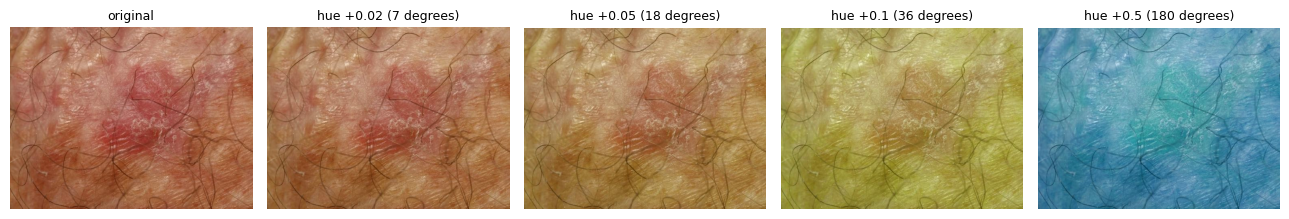

In [17]:
example = paths.find_image(sample.loc[sample["diagnosis_1"] == "Malignant", "isic_id"].iloc[0])
with Image.open(example) as im:
    pic = im.convert("RGB")
torch.manual_seed(SEED)
fig, axes = plt.subplots(1, 5, figsize=(13, 2.6))
axes[0].imshow(pic)
axes[0].set_title("original", fontsize=9)
for ax, h in zip(axes[1:], (0.02, 0.05, 0.1, 0.5)):
    ax.imshow(ColorJitter(hue=(h, h))(pic))     # the largest shift each setting can produce
    ax.set_title(f"hue +{h} ({h * 360:.0f} degrees)", fontsize=9)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

**(b)** On lesion pixels the Benign/Malignant gap is 6.3 degrees of hue (malignant lesions are redder) and 0.073 in brightness V (malignant lesions are lighter: pink BCCs against brown nevi). Hue jitter of 0.05 or more and brightness jitter of 0.3 or more move a lesion's colour further than the whole class gap, so they can erase the very cue a dermatologist uses; even hue 0.02 can shift it by up to 7 degrees. Safe: flips, 90-degree rotations and moderate crops, because orientation and framing carry no diagnosis, plus brightness and contrast around 0.1 (0.4 times the gap); risky: any hue or saturation jitter, stronger brightness, heavy blur (dermoscopic structures), elastic warps (border and asymmetry) and cutout over the lesion. A dermatologist has to approve the list with the ML engineer, because only a clinician can say whether a transformed lesion would still get the same diagnosis; the pipeline therefore uses brightness and contrast 0.1 and no hue or saturation jitter, stricter than the class example (brightness 0.3, which moves V by 1.2 times the gap here).

### A3.6 A lesion-level Dataset
`LesionDataset` and `aggregate_predictions` live in `shared/datasets.py` (Part B reuses them).

In [18]:
from torch.utils.data import DataLoader
from torchvision import transforms as T

from shared.datasets import LesionDataset, aggregate_predictions

show_source(LesionDataset, aggregate_predictions)

class LesionDataset(Dataset):
    """One lesion per item -> {view: tensor for each requested view, "label": int, "lesion_id": str}.

    lesion_table needs lesion_id, label_col and one <view>_id column per view (derm_id,
    clinical_id: the isic_id of each image). The transform runs separately on every view,
    so each view gets its own random augmentation. Missing files raise at construction.
    """

    def __init__(self, lesion_table, img_dir, label_col, transform, views=("derm", "clinical"),
                 label_map=None):
        self.table = lesion_table.reset_index(drop=True)
        self.views = tuple(views)
        unknown = set(self.views) - set(config.IMAGE_TYPES.values())
        if unknown:
            allowed = sorted(config.IMAGE_TYPES.values())
            raise ValueError(f"unknown views {sorted(unknown)}, use {allowed}")
        mapping = label_map or build_label_map().get(label_col)
        if mapping is None:
            mapping = {c: i for i, c in enumerate(so

In [19]:
# (a) one batch: shapes per view, and the labels match the lesion table
small = T.Compose([T.Resize(128), T.CenterCrop(128), T.ToTensor()])
dataset = LesionDataset(lesions, config.IMAGE_DIR, "diagnosis_1", small)
batch = next(iter(DataLoader(dataset, batch_size=8)))
for view in ("derm", "clinical"):
    print(view, tuple(batch[view].shape), batch[view].dtype)
    assert batch[view].shape == (8, 3, 128, 128)
expected = by_id.loc[batch["lesion_id"], "diagnosis_1"].map(dataset.class_to_index).tolist()
assert batch["label"].tolist() == expected
print("labels:", batch["label"].tolist(), "match the lesion table for", batch["lesion_id"][:3], "...")

# a missing image gives a clear error, before any training starts
broken = lesions.head(3).copy()
broken.loc[1, "clinical_id"] = "ISIC_0000000"
try:
    LesionDataset(broken, config.IMAGE_DIR, "diagnosis_1", small)
except FileNotFoundError as err:
    print("missing file ->", err)

derm (8, 3, 128, 128) torch.float32
clinical (8, 3, 128, 128) torch.float32
labels: [2, 2, 2, 2, 2, 2, 0, 2] match the lesion table for ['IL_0000652', 'IL_0003176', 'IL_0004688'] ...
missing file -> lesion IL_0003176: clinical image ISIC_0000000 is missing in milk10k/images


In [20]:
# (b) one epoch over 800 lesions: the labels seen equal the labels of the subset
subset = lesions.sample(800, random_state=SEED)
tiny = T.Compose([T.Resize(64), T.CenterCrop(64), T.ToTensor()])
loader = DataLoader(LesionDataset(subset, config.IMAGE_DIR, "diagnosis_1", tiny), batch_size=8, shuffle=True,
                    generator=torch.Generator().manual_seed(SEED))
seen = torch.cat([b["label"] for b in loader])
seen_counts = pd.Series(torch.bincount(seen, minlength=3).numpy(), index=CLASSES_3)
subset_counts = subset["diagnosis_1"].value_counts().reindex(CLASSES_3, fill_value=0)
assert (seen_counts.to_numpy() == subset_counts.to_numpy()).all()
print(pd.DataFrame({"seen in one epoch": seen_counts, "in the subset": subset_counts}).to_string())

               seen in one epoch  in the subset
Benign                       207            207
Indeterminate                 22             22
Malignant                    571            571


In [21]:
# (c) image-level probabilities -> one prediction per lesion, tested with synthetic probabilities
toy = images[images["lesion_id"].isin(subset["lesion_id"].iloc[:5])][["isic_id", "lesion_id", "image_type"]]
toy = toy.reset_index(drop=True)
rng = np.random.default_rng(SEED)
probs = rng.dirichlet(np.ones(3), size=len(toy))
out = aggregate_predictions(probs, toy, classes=CLASSES_3)

by_hand = (pd.DataFrame(probs, columns=CLASSES_3).assign(lesion_id=toy["lesion_id"])
           .groupby("lesion_id").mean())
assert np.allclose(out[CLASSES_3], by_hand) and (out["n_images"] == 2).all()
assert (out["pred"].to_numpy() == by_hand.to_numpy().argmax(axis=1)).all()
order = rng.permutation(len(toy))
assert np.allclose(aggregate_predictions(probs[order], toy.iloc[order], CLASSES_3)[CLASSES_3], out[CLASSES_3])

# the views disagree: dermoscopy says Malignant 0.9, the close-up says Benign 0.6 -> the average decides
pair = pd.DataFrame({"lesion_id": ["IL_demo", "IL_demo"]})
print(aggregate_predictions([[0.05, 0.05, 0.90], [0.60, 0.10, 0.30]], pair, CLASSES_3).round(3).to_string())
print("\naggregate_predictions: averages, argmax, one row per lesion, row order irrelevant: passed")

           Benign  Indeterminate  Malignant  n_images  pred
lesion_id                                                  
IL_demo     0.325          0.075        0.6         2     2

aggregate_predictions: averages, argmax, one row per lesion, row order irrelevant: passed


**(d)** The unit of evaluation is the lesion: the label, the clinical decision (biopsy or not) and the split all
belong to the lesion, so the two images are averaged into one prediction and metrics are computed over the 787 test
lesions. Per-image evaluation counts every lesion twice as if its views were independent, which narrows the
confidence intervals and lets a lesion count as half right when its views disagree. And if images rather than
lesions were split, the sibling oracle in A3.1 shows how much a model that recognises the lesion would gain from
seeing its other view in training.